# Portfolio Rebalancing Strategies

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 About This Notebook</h4>
This notebook demonstrates dynamic portfolio rebalancing strategies using the core Mean-CVaR optimization module. Rebalancing adapts portfolio weights in response to market changes, aiming to maintain optimal performance while accounting for transaction costs and turnover constraints.
<br><br>
Transaction cost model: <code>transaction_cost = transaction_cost_factor × turnover</code>, where turnover $=\lVert w-w_{pre} \rVert_1$.
<br><br>
We compare two rebalancing triggers:
<ul>
<li><a href="#percentage-change"><strong>Percentage Change</strong></a> — reoptimize when portfolio value drops below a threshold</li>
<li><a href="#drift-from-optimal"><strong>Drift from Optimal</strong></a> — reoptimize when current weights deviate from optimal by a specified norm</li>
</ul>
Both strategies are benchmarked against a buy-and-hold baseline using GPU (cuOpt) vs. CPU solvers.
</div>


In [ ]:
import os
import numpy as np
import cvxpy as cp

from cufolio import rebalance
from cufolio.cvar_parameters import CvarParameters
from cufolio.settings import (
    KDESettings,
    ReturnsComputeSettings,
    ScenarioGenerationSettings,
)

In [ ]:
# Global data settings.
# Define dataset paths and common parameters.
sp500_dataset_name = "sp500"
sp500_dataset_directory = f"../data/stock_data/{sp500_dataset_name}.csv"

# Define the settings for computing returns and scenario generation
rebal_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
rebal_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

In [3]:
# Define CVaR parameters for rebalancing with transaction costs and turnover constraints.
rebal_tc_cvar_params = CvarParameters(
    w_min=-0.3,
    w_max=0.8,
    c_min=0.1,
    c_max=0.4,
    L_tar=1.6,
    T_tar=0.5,        # Turnover constraint to limit trading activity.
    cvar_limit=None,
    risk_aversion=1,
    confidence=0.95,
)

## Strategy 1: Percentage Change Rebalancing
<a id='percentage-change'></a>

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Trigger Conditions</h4>
Re-optimization is triggered if either condition holds:
<ul>
<li>The percent change from the start to the end of the testing period drops below <code>pct_change_tolerance</code></li>
<li>The cumulative percent change since the <em>last positive</em> backtest period drops below <code>pct_change_tolerance</code></li>
</ul>
Example setup: 21-day (one-month) look-forward window and 252-day (one-year) look-back window for rolling optimization, with cuOpt as the GPU solver.
</div> 


BASELINE (BUY & HOLD) ANALYSIS
Period: 2022-07-01 to 2024-01-01
Strategy: Single optimization at start
Setting parameter log_to_console to false
Setting parameter method to 1

BASELINE COMPLETE
Final portfolio value: $0.90
Total return: -8.27%
Data points collected: 357

DYNAMIC REBALANCING ANALYSIS
Period: 2022-07-01 to 2024-01-01
Strategy: Percentage Change
Threshold: -0.005
Look-forward window: 21 days
Look-back window: 252 days
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-08-02 | Event #1 | Portfolio value: $0.96
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-09-30 | Event #2 | Portfolio value: $1.03
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-11-30 | Event #3 | Portfolio value: $0.99
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-12-30 | Event #4 | Portfolio v

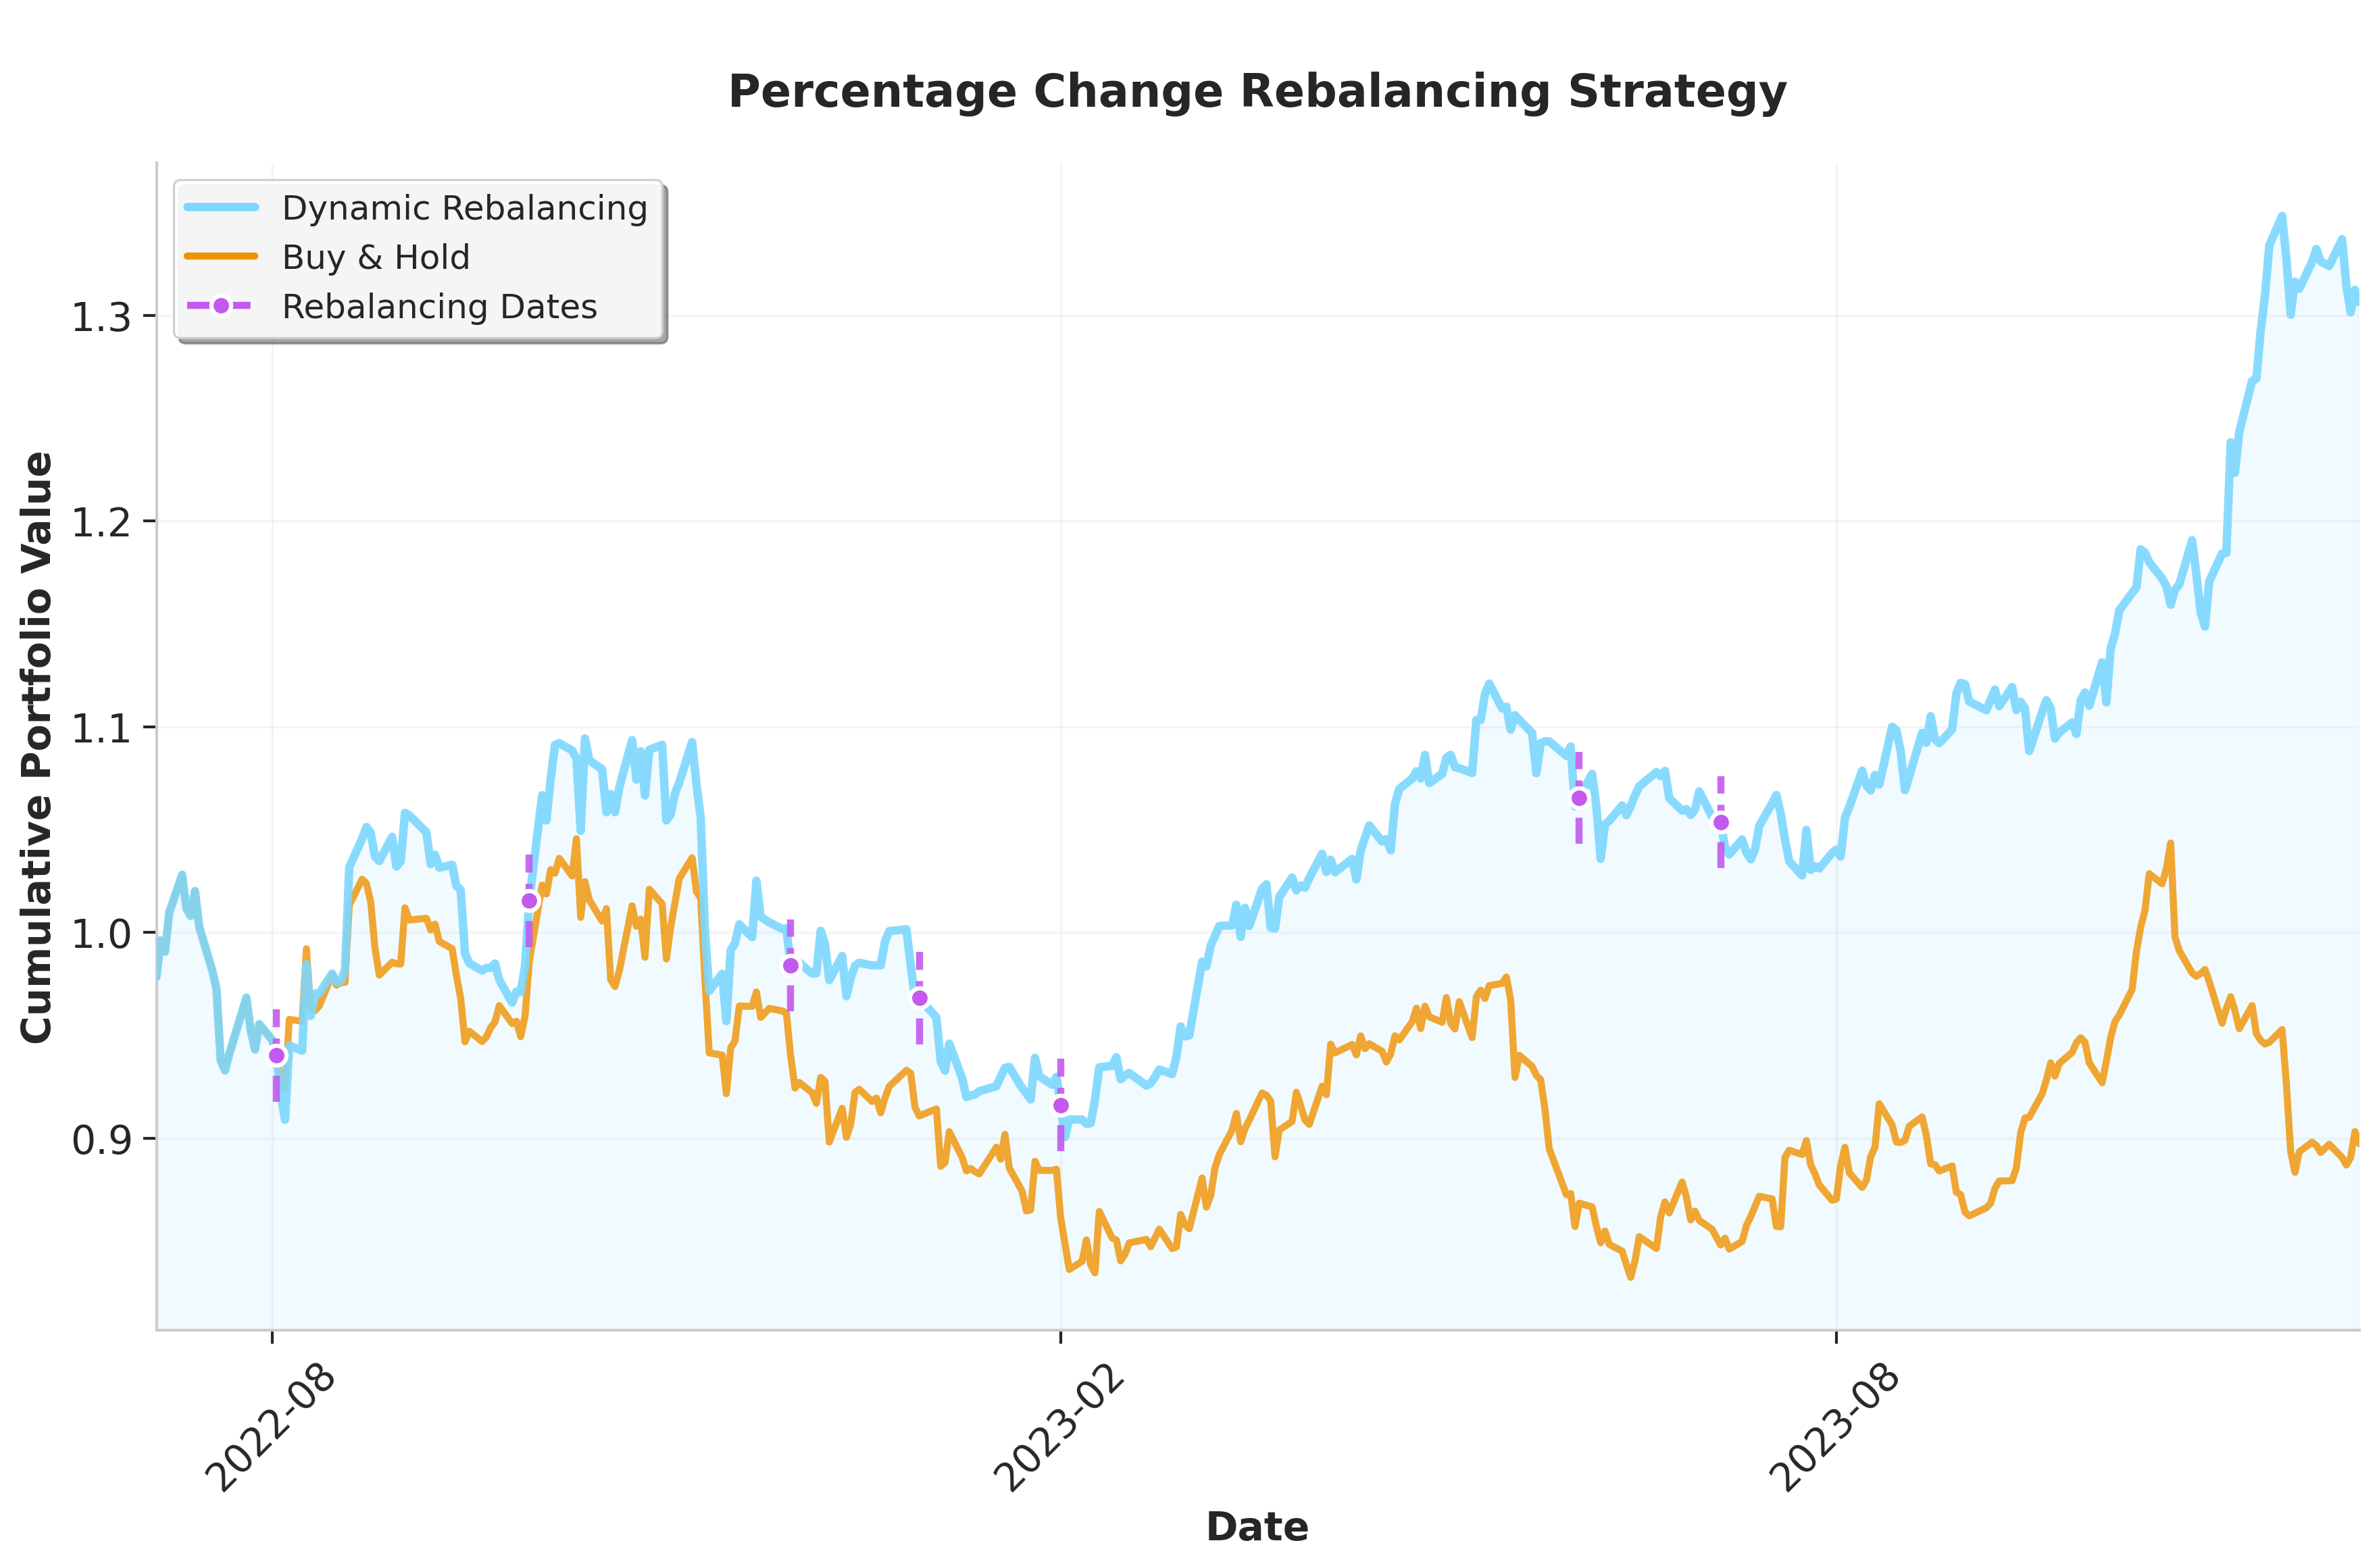

In [6]:
# Trading period and backtesting windows.
selected_rebal_scenario_name = 'rebalancing_trading_period'
rebal_trading_start_date, rebal_trading_end_date = "2022-07-01", "2024-01-01"

rebal_look_back_window = 252       # Historical period for optimization (trading days).
rebal_look_forward_window = 21     # Out-of-sample testing period (trading days).

# Transaction cost parameters
transaction_cost_factor = 0.001

# Reoptimization trigger: percentage change threshold.
percent_change_tolerance = -0.005   # Reoptimize if portfolio value drops by 0.5%.
pct_change_re_optimize_criteria = {"type": "pct_change", "threshold": percent_change_tolerance}

# GPU solver configuration.
solver_settings = {'solver':cp.CUOPT, 'verbose': False, 'solver_method': 'PDLP'}

# Execute portfolio rebalancing with percentage change trigger.
pct_change_rebalancing_obj = rebalance.rebalance_portfolio(
    dataset_directory=sp500_dataset_directory,
    returns_compute_settings = rebal_returns_compute_settings,
    scenario_generation_settings = rebal_scenario_generation_settings,
    trading_start=rebal_trading_start_date,
    trading_end=rebal_trading_end_date,
    look_forward_window=rebal_look_forward_window,
    look_back_window=rebal_look_back_window,
    cvar_params=rebal_tc_cvar_params,
    solver_settings = solver_settings,
    re_optimize_criteria=pct_change_re_optimize_criteria, #specify the re-optimization criteria
    print_opt_result = False
)

# Retrieve and plot optimization results.
pct_change_results_df, pct_change_re_optimize_dates, cumulative_portfolio_value_array = pct_change_rebalancing_obj.re_optimize(
                                                                                                                        transaction_cost_factor = transaction_cost_factor, \
                                                                                                                        plot_results=True, \
                                                                                                                        save_plot = True, \
                                                                                                                        results_dir = "../results/rebalancing_strategies"
                                                                                                                        )

## Strategy 2: Drift from Optimal Portfolio
<a id='drift-from-optimal'></a>

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Drift-Based Trigger</h4>
Over time the portfolio composition drifts from the original optimized allocation. Re-optimization is triggered when:
$$\lVert w_{cur} - w_{opt} \rVert_* > tol,$$
where:
<ul>
<li>$w_{cur}$ = Current portfolio weights</li>
<li>$w_{opt}$ = Optimal portfolio weights</li>
<li>$tol$ = <code>drift_tolerance</code></li>
<li>Norm $*$: 1-norm (absolute differences) or 2-norm (Euclidean distance)</li>
</ul>
</div>

BASELINE (BUY & HOLD) ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Single optimization at start
Setting parameter log_to_console to false
Setting parameter method to 1

BASELINE COMPLETE
Final portfolio value: $0.85
Total return: -13.38%
Data points collected: 420

DYNAMIC REBALANCING ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Drift From Optimal
Threshold: 0.05
Look-forward window: 42 days
Look-back window: 252 days
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-08-31 | Event #1 | Portfolio value: $0.98
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-10-31 | Event #2 | Portfolio value: $0.95


Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-12-30 | Event #3 | Portfolio value: $0.87
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-03-03 | Event #4 | Portfolio value: $0.78
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-05-03 | Event #5 | Portfolio value: $0.86
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-07-05 | Event #6 | Portfolio value: $0.81
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-09-01 | Event #7 | Portfolio value: $0.84
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-11-01 | Event #8 | Portfolio value: $0.89
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2024-01-03 | Event #9 | Portfolio value

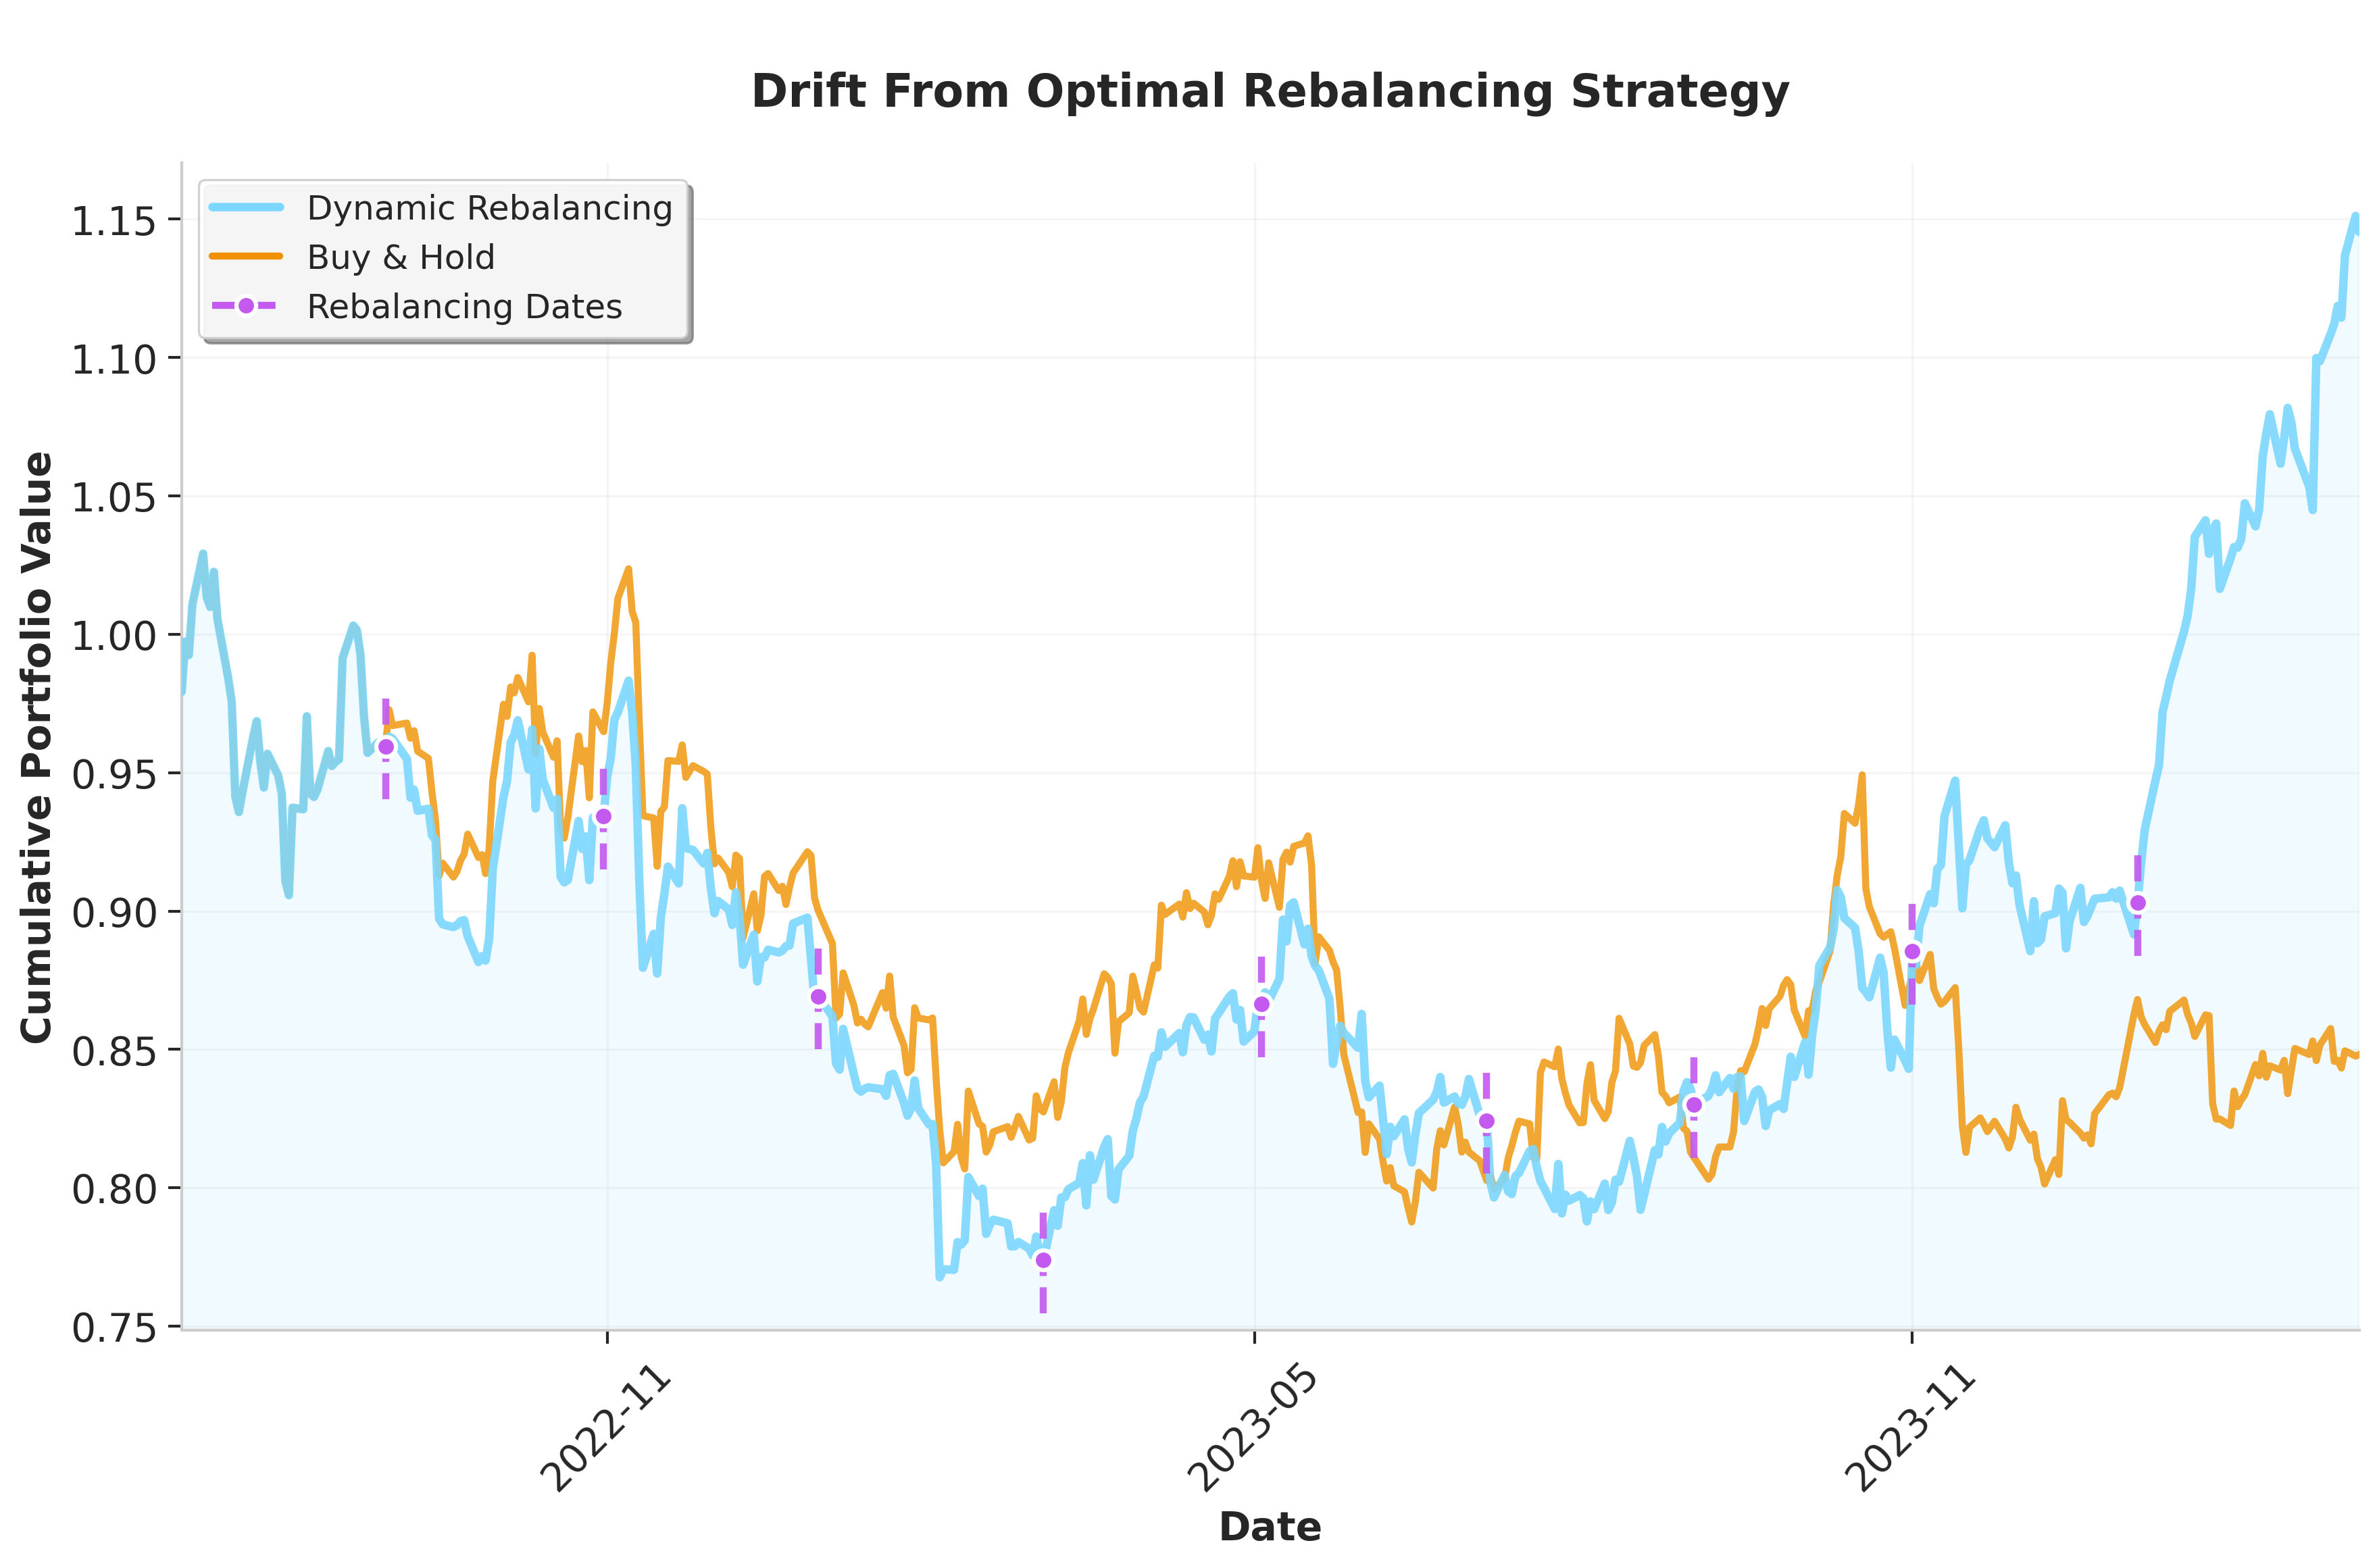

In [6]:
# --- Select Scenario for Rebalancing ---
selected_rebal_scenario_name = 'rebalancing_trading_period'
rebal_trading_start_date, rebal_trading_end_date = "2022-07-01", "2024-05-01"

# Look-back and look-forward windows for backtesting
rebal_look_back_window = 252       # Historical period used for optimization (trading days)
rebal_look_forward_window = 42     # Testing period (out-of-sample performance)

# Define drift tolerance threshold
drift_rebal_tolerance = 0.05        # Rebalance if weight deviation (L2 norm) exceeds tolerance

# Set re-optimization criteria for drift
drift_re_optimize_criteria = {
    "type": "drift_from_optimal",
    "threshold": drift_rebal_tolerance,
    "norm": 1,                # Using L2 norm
}

#GPU solver
solver_settings = {"solver": cp.CUOPT, "verbose": False, 'solver_method': 'PDLP'}

# Execute portfolio rebalancing
drift_rebalancing_obj = rebalance.rebalance_portfolio(
    dataset_directory=sp500_dataset_directory,
    returns_compute_settings = rebal_returns_compute_settings,
    scenario_generation_settings = rebal_scenario_generation_settings,
    trading_start=rebal_trading_start_date,
    trading_end=rebal_trading_end_date,
    look_forward_window=rebal_look_forward_window,
    look_back_window=rebal_look_back_window,
    cvar_params=rebal_tc_cvar_params,
    solver_settings = solver_settings,
    re_optimize_criteria=drift_re_optimize_criteria,
    print_opt_result=False
)

# Retrieve and plot results
drift_results_df, drift_re_optimize_dates, cumulative_portfolio_value_array = drift_rebalancing_obj.re_optimize(plot_results=True, save_plot = True, results_dir = "../results/rebalancing_strategies")

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 Why GPU Acceleration Matters Here</h4>
Portfolio optimization is a repeated core task rather than a one-time effort — the acceleration cuOpt delivers for a single solve is magnified in active trading environments. More sophisticated strategies with additional hyperparameters require countless optimization iterations. These examples highlight GPU-accelerated performance; finding optimal strategies for deployment requires many more iterations.
</div> 


SPDX-FileCopyrightText: Copyright (c) 2023-2025 NVIDIA CORPORATION & AFFILIATES. All rights reserved. 

SPDX-License-Identifier: Apache-2.0

Licensed under the Apache License, Version 2.0 (the "License");you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.